In [11]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
from tqdm import tqdm
import seaborn as sns 
from transformers import AutoTokenizer
import pandas as pd
from multiprocessing import Pool, cpu_count
import numpy as np

sns.set_style('whitegrid')

from scipy import stats
from statsmodels.stats.multitest import multipletests
import math

In [7]:
benchmark_name_dict = {
    "medmcqa": "MedMCQA",
    "medqa_test": "MedQA",
    "clinical_knowledge": "MMLU - clinical knowledge",
    "professional_medicine": "MMLU - professional medicine",
    "anatomy": "MMLU - anatomy",
    "medexpqa": "MedExpQA",
}

model_name_dict = {
    "Qwen2.5-3B-Instruct": "Q3B",
    "Qwen2.5-7B-Instruct": "Q7B",
    "NACC-3B": "LUNAR-OS-SCe",
    "NACC-3B-OS": "LUNAR-SCe",
    "NACC-3B-SCE": "LUNAR-OS",
    "NACC-3B-OS-SCE": "LUNAR",
}

model_order = [
    "Q3B",
    "LUNAR-OS-SCe",
    "LUNAR-SCe",
    "LUNAR-OS",
    "LUNAR",
    "Q7B",
    # "NACC-7B-OS",
    # "NACC-7B-OS-SCE",
]

# Get token counts

In [ ]:
def load_answers(dir_path, dataset_name):
    # load all parquet files from the directory, stack them into a pandas datafame
    # this only reads the participant ID, ground trush answer and the prediction,
    # which is significantly (about 100x) faster than loading the whole dataframe.
    # Loading everything is very slow because there are extremely long strings in some columns

    fpaths = list(dir_path.rglob("*.parquet"))

    dfs = []

    cols_to_read = [
        "ID",
        "ground_truth",
        "prediction",
        "generated_text",
        "finish_reason",
    ]

    for fpath in tqdm(fpaths):
        model = fpath.parent.name.split("-", 3)[-1]
        benchmark = fpath.parent.parent.name.split("_", 1)[-1].upper()

        # if benchmark not in ['COG','ETPR']:
        #     continue
        
        if benchmark in ['MCI','NP', 'NP_MIXED', 'FTLD']:
            print(f"Skipping {fpath.parent.parent.name}")
            continue

        df = pd.read_parquet(fpath, columns=cols_to_read)

        df = df.assign(model=model, benchmark=benchmark)

        df["correct"] = (df["ground_truth"] == df["prediction"]).astype(int)

        df["dataset"] = dataset_name

        dfs.append(df)

    df = pd.concat(dfs)

    df["model"] = df["model"].replace(model_name_dict)

    # make these columns Categorical
    group_cols = ["benchmark", "model", "prediction", "ground_truth"]
    for col in group_cols:
        df[col] = pd.Categorical(df[col])

    return df

In [4]:
directory = "/projectnb/vkolagrp/projects/adrd_foundation_model/results"
nifd_path = Path(f'{directory}/NIFD')
nacc_path = Path(f'{directory}/NACC')
adni_path = Path(f'{directory}/ADNI')
ppmi_path = Path(f'{directory}/PPMI')
brainlat_path = Path(f'{directory}/brainlat')

In [5]:
nifd = load_answers(nifd_path,dataset_name='NIFD')
adni = load_answers(adni_path,dataset_name='ADNI')
nacc = load_answers(nacc_path,dataset_name='NACC')
ppmi = load_answers(ppmi_path,dataset_name='PPMI')
brainlat = load_answers(brainlat_path,dataset_name='BrainLat')

  0%|          | 0/24 [00:00<?, ?it/s]

 42%|████▏     | 10/24 [00:00<00:00, 61.83it/s]

Skipping test_ftld
Skipping test_ftld
Skipping test_ftld
Skipping test_ftld
Skipping test_ftld
Skipping test_ftld
Skipping test_ftld
Skipping test_ftld


 25%|██▌       | 18/72 [00:01<00:01, 27.21it/s]

Skipping test_mci
Skipping test_mci
Skipping test_mci
Skipping test_mci
Skipping test_mci
Skipping test_mci
Skipping test_mci
Skipping test_mci


 58%|█████▊    | 42/72 [00:13<00:09,  3.20it/s]

Skipping test_np_mixed
Skipping test_np_mixed
Skipping test_np_mixed
Skipping test_np_mixed
Skipping test_np_mixed
Skipping test_np_mixed
Skipping test_np_mixed
Skipping test_np_mixed


 92%|█████████▏| 66/72 [00:25<00:02,  2.79it/s]

Skipping test_np
Skipping test_np
Skipping test_np
Skipping test_np
Skipping test_np
Skipping test_np
Skipping test_np
Skipping test_np


100%|██████████| 16/16 [00:01<00:00, 14.02it/s]


In [7]:
df = pd.concat([nifd,adni,nacc,ppmi,brainlat])

df = df[['dataset','benchmark','model','ID','generated_text','finish_reason','correct',]]

# only keep models we care about
df = df[df['model'].isin(model_order)]

In [8]:
df.shape

(2209860, 7)

In [9]:
df.sample(3)

,dataset,benchmark,model,ID,generated_text,finish_reason,correct
108290,NACC,ETPR,Q7B,NACC119364,To identify the primary etiology of the patien...,stop,1
3054,NACC,COG,LUNAR-OS-SCe,NACC840025,To determine the correct cognitive status for ...,stop,1
86319,NACC,ETPR,Q7B,NACC896337,"To identify the primary etiologic diagnosis, w...",stop,1


In [10]:
df['finish_reason'].value_counts()

finish_reason
stop      2209851
length          9
Name: count, dtype: int64

In [11]:
import os

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
# tokenizer_7b = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")

# Enable tokenizer parallelism explicitly
os.environ["TOKENIZERS_PARALLELISM"] = "true"

def count_tokens_fast(df, text_column, model_name="Qwen/Qwen2.5-3B-Instruct", batch_size=15000):
    """
    Fast token counting using the tokenizer's built-in parallelism
    This is typically faster than multiprocessing for this task
    """
    # tokenizer = AutoTokenizer.from_pretrained(model_name)
    texts = df[text_column].fillna('').tolist()
    
    token_counts = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]
        encoded = tokenizer(
            batch,
            add_special_tokens=False,
            truncation=False,
            padding=False,
            return_attention_mask=False
        )
        token_counts.extend([len(ids) for ids in encoded['input_ids']])
    
    return token_counts

# Usage:
# df['token_count'] = count_tokens_fast(df, 'your_text_column')

In [12]:
# ex = df
# .sample(1000000)

In [13]:
df['token_count'] = count_tokens_fast(df, 'generated_text',batch_size=1000)

 51%|█████     | 1132/2210 [04:48<05:22,  3.35it/s]

: 

# Plot

In [3]:
df = pd.read_csv("token_counts.csv")

/scratch/ipykernel_3499737/1631588112.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("token_counts.csv")


In [8]:
df.head()

,dataset,benchmark,model,ID,generated_text,finish_reason,correct,token_count
0,NIFD,COG,LUNAR,1_S_0119,To determine the correct cognitive status for ...,stop,0,340
1,NIFD,COG,LUNAR,1_S_0119,"To determine the patient's cognitive status, w...",stop,0,319
2,NIFD,COG,LUNAR,1_S_0119,To determine the correct cognitive status for ...,stop,0,290
3,NIFD,COG,LUNAR,1_S_0119,To determine the cognitive status of the patie...,stop,0,431
4,NIFD,COG,LUNAR,1_S_0119,To determine the correct cognitive status for ...,stop,0,377


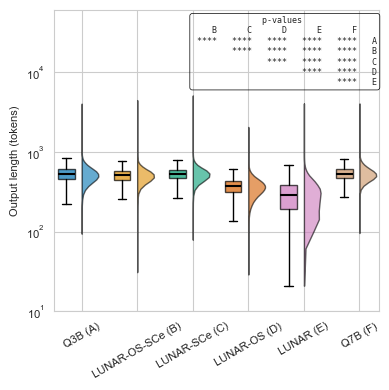


Statistical Test Results (Benjamini-Hochberg corrected):
Q3B (A) vs LUNAR-OS-SCe (B): Δ median = +14.0, p = 0.0000 (****)
Q3B (A) vs LUNAR-SCe (C): Δ median = -5.0, p = 0.0000 (****)
Q3B (A) vs LUNAR-OS (D): Δ median = +150.0, p = 0.0000 (****)
Q3B (A) vs LUNAR (E): Δ median = +231.0, p = 0.0000 (****)
Q3B (A) vs Q7B (F): Δ median = -9.0, p = 0.0000 (****)
LUNAR-OS-SCe (B) vs LUNAR-SCe (C): Δ median = -19.0, p = 0.0000 (****)
LUNAR-OS-SCe (B) vs LUNAR-OS (D): Δ median = +136.0, p = 0.0000 (****)
LUNAR-OS-SCe (B) vs LUNAR (E): Δ median = +217.0, p = 0.0000 (****)
LUNAR-OS-SCe (B) vs Q7B (F): Δ median = -23.0, p = 0.0000 (****)
LUNAR-SCe (C) vs LUNAR-OS (D): Δ median = +155.0, p = 0.0000 (****)
LUNAR-SCe (C) vs LUNAR (E): Δ median = +236.0, p = 0.0000 (****)
LUNAR-SCe (C) vs Q7B (F): Δ median = -4.0, p = 0.0000 (****)
LUNAR-OS (D) vs LUNAR (E): Δ median = +81.0, p = 0.0000 (****)
LUNAR-OS (D) vs Q7B (F): Δ median = -159.0, p = 0.0000 (****)
LUNAR (E) vs Q7B (F): Δ median = -240.0, p = 0

In [10]:

# Prepare data
_df = df
# _df['model'] = _df['model'].cat.remove_unused_categories()
_df = _df[_df['finish_reason'] == 'stop']

# Set up colors
palette = sns.color_palette("colorblind", n_colors=len(model_order))
color_map = {model: palette[i] for i, model in enumerate(model_order)}

# Create letter labels for models
letters = [chr(65 + i) for i in range(len(model_order))]  # A, B, C, D, ...
model_to_letter = {model: letter for model, letter in zip(model_order, letters)}

# Create figure
fig, ax = plt.subplots(figsize=(4,4))

# Plot for each model
positions = np.arange(len(model_order))
violin_width = 0.6
box_width = 0.3
fontsize = 8

for i, model in enumerate(model_order):
    model_data = _df[_df['model'] == model]['token_count'].values
    color = color_map[model]
    
    # Create half violin (right side only)
    parts = ax.violinplot(
        [model_data],
        positions=[i],
        widths=violin_width,
        showmeans=False,
        showextrema=False,
        showmedians=False
    )
    
    # Modify violin to show only right half and color it
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)
        
        # Get the paths and modify to show only right half
        m = np.mean(pc.get_paths()[0].vertices[:, 0])
        pc.get_paths()[0].vertices[:, 0] = np.clip(
            pc.get_paths()[0].vertices[:, 0], m, np.inf
        )
    
    # Add box plot (on the left side)
    bp = ax.boxplot(
        [model_data],
        positions=[i - violin_width/2 - box_width/2 + 0.175],
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=1.5),
        boxprops=dict(facecolor=color, edgecolor='black', alpha=0.7),
        whiskerprops=dict(color='black', linewidth=1),
        capprops=dict(color='black', linewidth=1)
    )

# Helper functions for p-value matrix annotation
def map_values(value):
    if isinstance(value, str):
        return value
    if pd.isna(value):
        return ""
    if value < 0.0001:
        return "****"
    elif value < 0.001:
        return "***"
    elif value < 0.01:
        return "**"
    elif value < 0.05:
        return "*"
    elif value <= 1.0:
        return "ns"
    else:
        return str(value)

def get_annotate_matrix(matrix_content: pd.DataFrame):
    """Modified to properly show upper triangular with A (rows) vs B,C,D... (cols)"""
    n = len(matrix_content)
    row_labels = matrix_content.index.tolist()  # A, B, C, D, E (rows)
    col_labels = matrix_content.columns.tolist()[1:]  # B, C, D, E, F (columns, skip A)
    
    # Build header row with column labels - add empty space for row label column
    main = []
    header = ["  "] + ["{: <5}".format(label) for label in col_labels]
    main.append("  ".join(header))
    
    # Build data rows (only upper triangle)
    for i in range(n - 1):  # Don't include last row (has no comparisons)
        row_data = []
        for j in range(i + 1, n):  # Only columns to the right
            val = matrix_content.iloc[i, j]
            row_data.append("{: <5}".format(map_values(val)))
        
        # Pad with empty spaces for columns before the first value
        padding = ["     "] * i
        row_values = padding + row_data
        
        # Add row label at the end
        row_line = "  ".join(row_values) + "  " + row_labels[i]
        main.append(row_line)
    
    return main

def pairwise_tests_matrix_same_as_original(df, order, model_to_letter):
    models_to_compare = [str(m) for m in order]
    # Use letter labels for the matrix
    letter_labels = [model_to_letter[m] for m in models_to_compare]
    
    pairs = [(models_to_compare[i], models_to_compare[j])
             for i in range(len(models_to_compare))
             for j in range(i + 1, len(models_to_compare))]

    p_values = []
    median_diffs = []

    for model1, model2 in pairs:
        data1 = df[df["model"] == model1]["token_count"].values
        data2 = df[df["model"] == model2]["token_count"].values

        # Two-sided Welch t-test
        t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)
        p_values.append(p_val)

        median1 = np.median(data1)
        median2 = np.median(data2)
        median_diffs.append(median1 - median2)

    # BH correction
    reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

    # Build matrix with letter labels
    mat = pd.DataFrame(np.nan, index=letter_labels, columns=letter_labels)
    for idx, (m1, m2) in enumerate(pairs):
        letter1 = model_to_letter[m1]
        letter2 = model_to_letter[m2]
        mat.loc[letter1, letter2] = p_adjusted[idx]
        mat.loc[letter2, letter1] = p_adjusted[idx]
    np.fill_diagonal(mat.values, np.nan)

    return mat, pairs, p_adjusted, median_diffs

def annotate_pmatrix(ax, matrix_content, xy=(0.995, 0.98), title="p-values"):
    matrix_text_lines = get_annotate_matrix(matrix_content)
    matrix_text_lines.insert(0, f"{title}")
    matrix_text = "\n".join(matrix_text_lines)

    ax.annotate(
        matrix_text,
        xy=xy, xycoords="axes fraction",
        ha="right", va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            edgecolor="black",
            facecolor=(1, 1, 1, 0.0),
            lw=0.5
        ),
        fontsize=fontsize-2,
        family='monospace'  # Use monospace for better alignment
    )

# Statistical testing and annotation
p_matrix_adj, pairs, p_adjusted, median_diffs = pairwise_tests_matrix_same_as_original(_df, model_order, model_to_letter)
annotate_pmatrix(ax, p_matrix_adj, xy=(0.995, 0.98), title="p-values               ")

# Customize plot
ax.set_xticks(positions)
# Add letter labels in brackets with model names
xticklabels = [f"{model} ({model_to_letter[model]})" for model in model_order]
ax.set_xticklabels(xticklabels, rotation=30, ha='center')
ax.set_ylabel('Output length (tokens)', fontsize=fontsize)
ax.set_yscale('log')
ax.grid(axis='y', alpha=1, linestyle='-')
ax.set_xlim(-0.5, len(model_order) - 0.65)

ax.tick_params(axis="both", labelsize=fontsize)

# Adjust y-limit to accommodate significance bars
ax.set_ylim(10, 6e4)

plt.tight_layout()
plt.show()

# Print results
print("\nStatistical Test Results (Benjamini-Hochberg corrected):")
for idx, (model1, model2) in enumerate(pairs):
    sig_label = map_values(p_adjusted[idx])
    letter1 = model_to_letter[model1]
    letter2 = model_to_letter[model2]
    print(f"{model1} ({letter1}) vs {model2} ({letter2}): Δ median = {median_diffs[idx]:+.1f}, p = {p_adjusted[idx]:.4f} ({sig_label})")

In [29]:

def map_values(value):
    if isinstance(value, str):
        return value
    if pd.isna(value):
        return ""
    if value < 0.0001:
        return "****"
    elif value < 0.001:
        return "***"
    elif value < 0.01:
        return "**"
    elif value < 0.05:
        return "*"
    elif value <= 1.0:
        return "ns"
    else:
        return str(value)


def get_annotate_matrix(matrix_content: pd.DataFrame):
    """Build upper-triangular p-value matrix text for annotation."""
    n = len(matrix_content)
    row_labels = matrix_content.index.tolist()
    col_labels = matrix_content.columns.tolist()[1:]  # skip A

    main = []
    header = ["  "] + ["{: <5}".format(label) for label in col_labels]
    main.append("  ".join(header))

    for i in range(n - 1):
        row_data = []
        for j in range(i + 1, n):
            val = matrix_content.iloc[i, j]
            row_data.append("{: <5}".format(map_values(val)))

        padding = ["     "] * i
        row_line = "  ".join(padding + row_data) + "  " + row_labels[i]
        main.append(row_line)

    return main


def annotate_pmatrix(ax, matrix_content, xy=(0.995, 0.98), title="p-values", fontsize=8):
    matrix_text_lines = get_annotate_matrix(matrix_content)
    matrix_text_lines.insert(0, title)
    matrix_text = "\n".join(matrix_text_lines)

    ax.annotate(
        matrix_text,
        xy=xy, xycoords="axes fraction",
        ha="right", va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            edgecolor="black",
            facecolor=(1, 1, 1, 0.0),
            lw=0.5,
        ),
        fontsize=fontsize - 2,
        family="monospace",
    )


def pairwise_tests_matrix(df, model_order, model_to_letter, value_col="token_count"):
    """Welch t-tests with BH correction; returns letter-labelled p-value matrix."""
    models = [str(m) for m in model_order]
    letter_labels = [model_to_letter[m] for m in models]

    pairs = [
        (models[i], models[j])
        for i in range(len(models))
        for j in range(i + 1, len(models))
    ]

    p_values, median_diffs = [], []
    for m1, m2 in pairs:
        d1 = df[df["model"] == m1][value_col].values
        d2 = df[df["model"] == m2][value_col].values
        _, p_val = stats.ttest_ind(d1, d2, equal_var=False)
        p_values.append(p_val)
        median_diffs.append(np.median(d1) - np.median(d2))

    _, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

    mat = pd.DataFrame(np.nan, index=letter_labels, columns=letter_labels)
    for idx, (m1, m2) in enumerate(pairs):
        l1, l2 = model_to_letter[m1], model_to_letter[m2]
        mat.loc[l1, l2] = p_adjusted[idx]
        mat.loc[l2, l1] = p_adjusted[idx]
    np.fill_diagonal(mat.values, np.nan)

    return mat, pairs, p_adjusted, median_diffs


# ---------------------------------------------------------------------------
# Main plot function
# ---------------------------------------------------------------------------

def plot_token_distribution(
    df,
    model_order,
    value_col="token_count",
    finish_reason_filter="stop",
    figsize=(4, 4),
    fontsize=8,
    ylim=(10, 6e4),
    ylabel="Output length (tokens)",
    palette="colorblind",
):
    """
    Half-violin + boxplot per model with a p-value matrix annotation and a
    dedicated legend panel below the main axes (same pattern as
    plot_bootstrap_accuracy).

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: 'model', value_col, and optionally 'finish_reason'.
    model_order : list
        Ordered list of model names.
    value_col : str
        Column to plot (default 'token_count').
    finish_reason_filter : str or None
        If not None, filter df to rows where finish_reason == this value.
    figsize : tuple
        Size of the full figure.
    fontsize : int
        Base font size.
    ylim : tuple
        y-axis limits.
    ylabel : str
        y-axis label.
    palette : str
        Seaborn palette name.

    Returns
    -------
    fig : matplotlib.figure.Figure
    axs : list[ax, ax_legend]
    """
    # ------------------------------------------------------------------
    # Data prep
    # ------------------------------------------------------------------
    _df = df.copy()
    if finish_reason_filter is not None and "finish_reason" in _df.columns:
        _df = _df[_df["finish_reason"] == finish_reason_filter]

    colors = sns.color_palette(palette, n_colors=len(model_order))
    color_map = {model: colors[i] for i, model in enumerate(model_order)}

    letters = [chr(65 + i) for i in range(len(model_order))]
    model_to_letter = {model: letter for model, letter in zip(model_order, letters)}

    # ------------------------------------------------------------------
    # Figure: main axes + dedicated legend panel (GridSpec, like
    # plot_bootstrap_accuracy)
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[20, 1], hspace=0.3)
    ax = fig.add_subplot(gs[0])
    ax_legend = fig.add_subplot(gs[1])
    ax_legend.axis("off")

    # ------------------------------------------------------------------
    # Draw half-violin + boxplot
    # ------------------------------------------------------------------
    positions = np.arange(len(model_order))
    violin_width = 0.6
    box_width = 0.3

    legend_handles = []

    for i, model in enumerate(model_order):
        model_data = _df[_df["model"] == model][value_col].values
        color = color_map[model]

        # Half violin (right side only)
        parts = ax.violinplot(
            [model_data],
            positions=[i],
            widths=violin_width,
            showmeans=False,
            showextrema=False,
            showmedians=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.6)
            pc.set_edgecolor("black")
            pc.set_linewidth(0.8)
            # Clip to right half
            m = np.mean(pc.get_paths()[0].vertices[:, 0])
            pc.get_paths()[0].vertices[:, 0] = np.clip(
                pc.get_paths()[0].vertices[:, 0], m, np.inf
            )

        # Boxplot (left side)
        ax.boxplot(
            [model_data],
            positions=[i - violin_width / 2 - box_width / 2 + 0.175],
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="black", linewidth=0.8),
            boxprops=dict(facecolor=color, edgecolor="black", alpha=0.7),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
        )

        # Collect handle for legend
        from matplotlib.patches import Patch
        legend_handles.append(
            Patch(facecolor=color, edgecolor="black", alpha=0.8,
                  label=f"{model} ({model_to_letter[model]})")
        )

    # ------------------------------------------------------------------
    # Statistical annotation
    # ------------------------------------------------------------------
    p_matrix, pairs, p_adjusted, median_diffs = pairwise_tests_matrix(
        _df, model_order, model_to_letter, value_col=value_col
    )
    annotate_pmatrix(ax, p_matrix, xy=(0.995, 0.98),
                     title="p-values               ", fontsize=fontsize)

    # ------------------------------------------------------------------
    # Axis formatting
    # ------------------------------------------------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels([])
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=1, linestyle="-")
    ax.set_xlim(-0.5, len(model_order) - 0.65)
    ax.tick_params(axis="both", labelsize=fontsize)
    ax.set_ylim(*ylim)

    # ------------------------------------------------------------------
    # Legend panel — mirrors plot_bootstrap_accuracy
    # ------------------------------------------------------------------
    ncol = math.ceil(len(model_order) / 2)
    ax_legend.legend(
        handles=legend_handles,
        loc="center",
        ncol=ncol,
        frameon=False,
        fontsize=fontsize - 2,
        handlelength=1.5,
        handleheight=1.5,
        bbox_to_anchor=(0.5, 0),
    )

    plt.tight_layout()

    # # ------------------------------------------------------------------
    # # Print results
    # # ------------------------------------------------------------------
    # print("\nStatistical Test Results (Benjamini-Hochberg corrected):")
    # for idx, (m1, m2) in enumerate(pairs):
    #     sig = map_values(p_adjusted[idx])
    #     l1, l2 = model_to_letter[m1], model_to_letter[m2]
    #     diff = median_diffs[idx]
    #     print(
    #         f"{m1} ({l1}) vs {m2} ({l2}): "
    #         f"Δ median = {diff:+.1f}, p = {p_adjusted[idx]:.4f} ({sig})"
    #     )

    return fig, [ax, ax_legend]

/scratch/ipykernel_3499737/2534548429.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


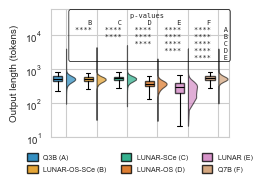

In [30]:
fig, [ax, ax_legend] = plot_token_distribution(
    df=df,
    model_order=model_order,
    value_col="token_count",          # column to plot
    finish_reason_filter="stop",      # set to None to skip filtering
    figsize=(2.3, 2),
    fontsize=7,
    ylim=(10, 6e4),
    ylabel="Output length (tokens)",
    palette="colorblind",
)
plt.show()

In [31]:
fig.savefig('../figures/fig2_output_length_all.pdf', dpi=200, format="pdf", bbox_inches="tight")

In [ ]:
# Make an ANOVA and then the tukey test for posthoc comparison between pairs